In [3]:
from scipy import integrate
import numpy as np
import matplotlib.pyplot as plt

In [20]:
a = 0.0
b = 1.0
lambda_0 = 0.5
epsilon = 1e-3
h = 0.05 

def y(t):
    return -5 * np.ones_like(t)

def kernel(t, s):
    return t / (1.0 + s)

def exact_solution(t, lam):
    ln2 = np.log(2)
    B = -5 * lam * ln2 / (1 - lam * (1 - ln2))
    return -5 + B * t

t_grid = np.arange(a, b + h, h)
s_grid = t_grid
N_points = len(t_grid)

x_prev = y(t_grid)
x_curr = np.zeros_like(x_prev)

q = lambda_0 * np.log(2)
stop_criterion_diff = epsilon * (1 - q) / q

In [21]:

for n in range(1, 30):
    for i in range(N_points):
        t_i = t_grid[i]
        integrand_values = kernel(t_i, s_grid) * x_prev
        integral_val = integral_val = integrate.simpson(integrand_values, x=s_grid)
        x_curr[i] = -5 + lambda_0 * integral_val

    diff_norm = np.max(np.abs(x_curr - x_prev))
    aposteriori_error = (q / (1 - q)) * diff_norm
    
    print(f"Итерация {n}: ||x_{n} - x_{n-1}|| = {diff_norm:.6f}, Апостериорная ошибка ≈ {aposteriori_error:.6f}")

    if aposteriori_error < epsilon:
        print(f"\nТочность ε = {epsilon} достигнута на итерации {n}.")
        break
        
    x_prev = np.copy(x_curr)
else:
    print("\nПревышено максимальное число итераций, точность не достигнута.")

Итерация 1: ||x_1 - x_0|| = 1.732868, Апостериорная ошибка ≈ 0.919103
Итерация 2: ||x_2 - x_1|| = 0.265868, Апостериорная ошибка ≈ 0.141015
Итерация 3: ||x_3 - x_2|| = 0.040791, Апостериорная ошибка ≈ 0.021635
Итерация 4: ||x_4 - x_3|| = 0.006258, Апостериорная ошибка ≈ 0.003319
Итерация 5: ||x_5 - x_4|| = 0.000960, Апостериорная ошибка ≈ 0.000509

Точность ε = 0.001 достигнута на итерации 5.


In [22]:
x_approx = x_curr
x_exact_values = exact_solution(t_grid, lambda_0)
x_initial = y(t_grid)

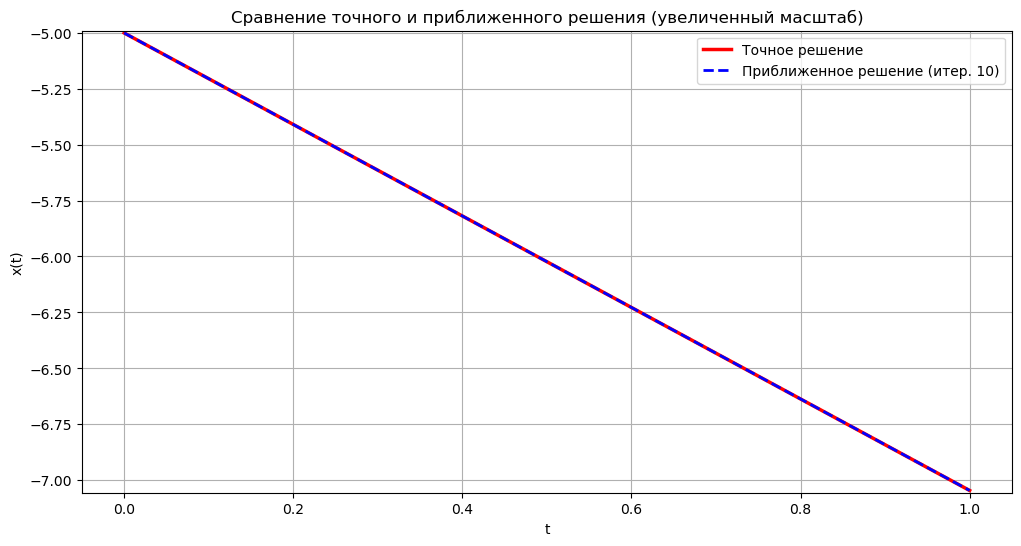

In [30]:
delta = 0.01  

plt.figure(figsize=(12, 6))

plt.plot(t_grid, x_exact_values, 'r-', label='Точное решение', linewidth=2.5)
plt.plot(t_grid, x_approx, 'b--', label=f'Приближенное решение (итер. {n})', linewidth=2)

y_min = min(np.min(x_exact_values), np.min(x_approx)) - delta
y_max = max(np.max(x_exact_values), np.max(x_approx)) + delta
plt.ylim(y_min, y_max)

plt.title('Сравнение точного и приближенного решения (увеличенный масштаб)')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.grid(True)
plt.legend()
plt.show()
